# 01 · Introduction to Information Fusion
**Based on:** *Introduction to Data Fusion* — Erik Blasch, FUSION Boot Camp 2026.

### Lecture take-aways
1. **What is Data Fusion?** — Fusion reduces uncertainty; the quantification of uncertainty is the covariance `P`.
2. **Methods:** data registration = correlation; data fusion = data association.
3. **What fusion *can* and *cannot* do:** it extends space/time coverage and reduces data overload; it is not a 'magic number', does not fix bad data, and does not replace human reasoning.
4. **Architectures:** the JDL/DFIG model, levels 0–5 (taxonomy); multidomain sensing (space, air, cyber) combining hard (images) and soft (text) sources.

## A. A brief history of the fusion idea
Blasch places information fusion in a long lineage of 'integration of the senses' and inference:

| Era | Contribution |
|-----|--------------|
| Greeks | Plato — propositions/beliefs/evidence; Aristotle — the soul integrates the senses |
| Materialism | Descartes — body and mind; causal interaction (matter and motion) |
| 1500–1700 | Kepler, Galileo, Newton — motion and dynamic interaction |
| 1700 | Bayes — beliefs (probability) |
| 1800 | Experimentalists — response to a stimulus |
| 1900 | Galton, Pearson — correlation (association); William James — integration of senses (FUSE) |
| 1960 | **Kalman Filter** |
| 1990 | First set of books on Sensor & Data Fusion |

### Fusion as a science: three gateways
* **Ontology** — what 'the world' is and its constructs (a declaration of what exists; e.g. sensing).
* **Epistemology** — the rules of the game; how we know something (the fusion rules).
* **Taxonomy** — classification/semantics of the information.

## B. Types of inference in high-level fusion

| | Inductive | Deductive | Abductive |
|---|-----------|-----------|-----------|
| Action | from observation to general understanding | derive a consequence from a law | infer the most plausible explanation of an observation |
| Direction | specific to general | general to specific | incorporate relations |
| Methods | Probability, Bayesian, entropy | If-then, hypothesis tests | Bayes Nets |

*(E. Blasch, P. Valin, E. Bossé, "Measures of Effectiveness for High-Level Fusion," Fusion 2010.)*

## C. The Key Fusion Equation
The central claim: **fusion reduces uncertainty**. When two independent measurements of the same quantity are 
fused, with variances $P_1, P_2$ (or $\sigma_1^2,\sigma_2^2$), the fused estimate has a variance **smaller than either**:

$$\frac{1}{P_F} = \frac{1}{P_1} + \frac{1}{P_2} \quad\Longrightarrow\quad P_F = \frac{P_1 P_2}{P_1 + P_2}$$

(adapted from Maybeck, 1978). This is exactly the fusion of two Gaussians — equivalent to a Kalman measurement update.

**Slide example:** with $\sigma_1^2=1$ and $\sigma_2^2=4$ we get $P_F = \tfrac{1\cdot4}{1+4}=0.8$, i.e. $\sigma_F=\sqrt{0.8}\approx0.90$ — smaller than $\sigma_1=1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fuse(x1, P1, x2, P2):
    """Fuse two independent Gaussian estimates (scalar or matrix).
    Returns the fused estimate and the fused covariance."""
    P1, P2 = np.asarray(P1, float), np.asarray(P2, float)
    if P1.ndim == 0:  # scalar
        PF = (P1 * P2) / (P1 + P2)
        xF = PF * (x1 / P1 + x2 / P2)
        return xF, PF
    PF = np.linalg.inv(np.linalg.inv(P1) + np.linalg.inv(P2))  # information-form fusion
    xF = PF @ (np.linalg.inv(P1) @ x1 + np.linalg.inv(P2) @ x2)
    return xF, PF

# Slide example
xF, PF = fuse(0.0, 1.0, 0.0, 4.0)
print(f'P_F = {PF:.3f},  sigma_F = {np.sqrt(PF):.3f}  (smaller than sigma_1=1 and sigma_2=2)')

P_F = 0.800,  sigma_F = 0.894  (smaller than sigma_1=1 and sigma_2=2)


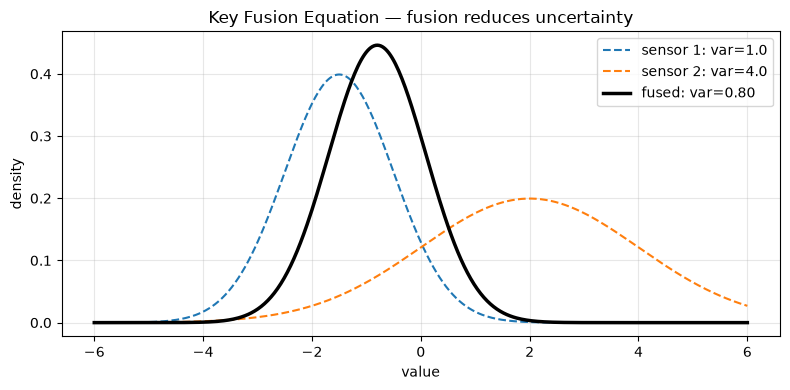

Note: the fused density is taller and narrower -> smaller variance.


In [2]:
# Visualization: two Gaussians and the fused Gaussian
from math import sqrt, pi
x = np.linspace(-6, 6, 400)
def gauss(x, mu, var):
    return np.exp(-(x-mu)**2/(2*var))/sqrt(2*pi*var)

x1, P1, x2, P2 = -1.5, 1.0, 2.0, 4.0
xf, Pf = fuse(x1, P1, x2, P2)
plt.figure(figsize=(8,4))
plt.plot(x, gauss(x, x1, P1), '--', label=f'sensor 1: var={P1}')
plt.plot(x, gauss(x, x2, P2), '--', label=f'sensor 2: var={P2}')
plt.plot(x, gauss(x, xf, Pf), 'k', lw=2.5, label=f'fused: var={Pf:.2f}')
plt.title('Key Fusion Equation — fusion reduces uncertainty')
plt.xlabel('value'); plt.ylabel('density'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('Note: the fused density is taller and narrower -> smaller variance.')

### Covariance ellipse reduction — the 2-D case
When two sensors measure position in the plane with different error ellipses (e.g. a radar accurate in range 
but not in angle, and an optical sensor the other way around), fusion shrinks the ellipse area — the very 
principle behind triangulation.

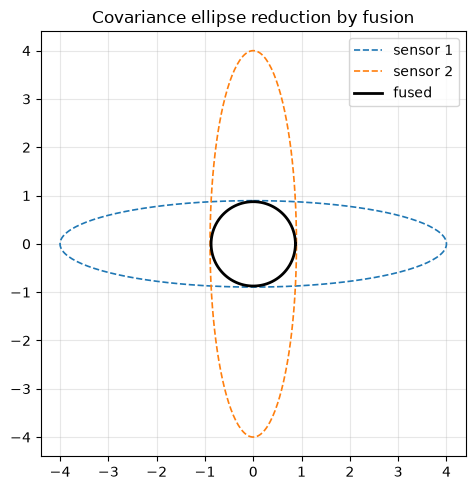

det(P1)=0.800 det(P2)=0.800 det(P_F)=0.036  (fused ellipse area is much smaller)


In [3]:
def cov_ellipse(P, mean=(0,0), n_std=2.0, **kw):
    vals, vecs = np.linalg.eigh(P)
    t = np.linspace(0, 2*np.pi, 200)
    circle = np.array([np.cos(t), np.sin(t)])
    ell = vecs @ np.diag(n_std*np.sqrt(vals)) @ circle
    return ell[0]+mean[0], ell[1]+mean[1]

P1 = np.array([[4.0, 0.0],[0.0, 0.2]])   # accurate along y, coarse along x
P2 = np.array([[0.2, 0.0],[0.0, 4.0]])   # the other way
xF, PF = fuse(np.zeros(2), P1, np.zeros(2), P2)

plt.figure(figsize=(5,5))
for P, lab, st in [(P1,'sensor 1','C0--'),(P2,'sensor 2','C1--'),(PF,'fused','k-')]:
    ex, ey = cov_ellipse(P)
    plt.plot(ex, ey, st, lw=2 if lab=='fused' else 1.2, label=lab)
plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=.3)
plt.title('Covariance ellipse reduction by fusion'); plt.tight_layout(); plt.show()
print('det(P1)=%.3f det(P2)=%.3f det(P_F)=%.3f  (fused ellipse area is much smaller)'
      % (np.linalg.det(P1), np.linalg.det(P2), np.linalg.det(PF)))

## D. The JDL/DFIG model — fusion levels 0–5
The standard taxonomy for describing fusion functions (originally JDL, extended to DFIG in 2006):

| Level | Name | Description |
|-------|------|-------------|
| **L0** | Sub-object / Signal | registration and signal processing, feature extraction |
| **L1** | Object assessment | detection, identification (classification) and tracking of objects |
| **L2** | Situation assessment | estimating relations among entities; the situational picture |
| **L3** | Threat / Impact assessment | estimating threat, intent, and future consequences |
| **L4** | Process refinement | sensor management and control |
| **L5** | User refinement | the human in the loop — display, interaction, decision |

*("DFIG (Data Fusion Information Group), Situation Assessment", J. of Adv. in Info. Fusion, Dec. 2006.)*

**What we can do today (Can Do):** image registration (L0), detection/identification and tracking of 
non-maneuvering targets in sparse environments (L1), limited automated reasoning at L2/L3, optimization for 
commensurate sensors at L4, and providing estimates to the user at L5.  
**What is still hard (Can NOT Do):** accurate tracking of maneuvering targets in dense environments, 
approaching human reasoning ability, accurately modeling intent, and optimizing distributed non-commensurate sensors.

In [4]:
# Inference hierarchy — from signal level to knowledge level
levels = [
    ('L0 signal',    'Signal Processing',   'detection, features'),
    ('L1 object',    'Estimation',          'Kalman/Bayesian, MAP'),
    ('L2 situation', 'Decision-level',      'Bayesian nets, fuzzy, NN'),
    ('L3 threat',    'Knowledge-based',     'expert systems, CBR'),
    ('L4/L5 mgmt',   'Control / User',      'sensor mgmt, human-in-loop'),
]
print(f"{'Level':<14}{'Techniques':<22}{'Examples'}")
print('-'*60)
for lv, tech, ex in levels:
    print(f'{lv:<14}{tech:<22}{ex}')

Level         Techniques            Examples
------------------------------------------------------------
L0 signal     Signal Processing     detection, features
L1 object     Estimation            Kalman/Bayesian, MAP
L2 situation  Decision-level        Bayesian nets, fuzzy, NN
L3 threat     Knowledge-based       expert systems, CBR
L4/L5 mgmt    Control / User        sensor mgmt, human-in-loop


## E. Advantages and disadvantages

**Advantages (Waltz & Llinas, 1990):** robust performance (redundancy), extended spatial and temporal 
coverage, increased confidence and reduced ambiguity, improved detection and resolution, increased 
dimensionality of the measurement space (resistance to jamming).  
In short: *extends spectral/spatial/temporal coverage and reduces uncertainty and ambiguity; reduces signal-to-noise ratio.*

**Disadvantages / pitfalls:** fusing dependent data (double counting), fusing inconsistent multimodal data, 
fusing bad data with good, a meaningless fused estimate, over-reliance on 'the number', and not understanding 
the algorithm's assumptions (most algorithms assume independence).

> **Data fusion "secrets" (D. Hall):** there is no substitute for a good sensor; downstream processing cannot 
> absolve bad upstream processing; the fused answer may be worse than the best sensor; there are no magic 
> algorithms; there will never be enough training data.

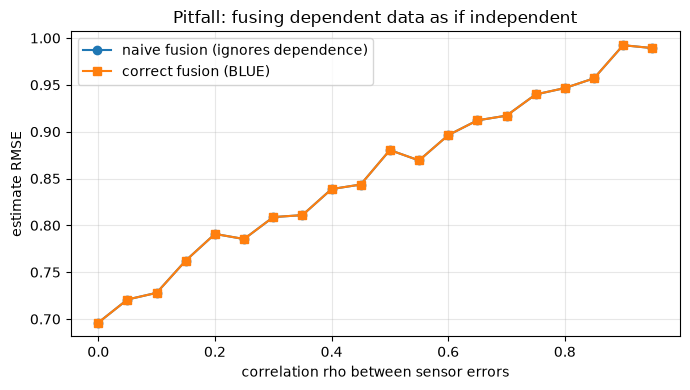

In [5]:
# Quantitative illustration of a pitfall: fusing two *dependent* measurements as if independent
# Assume correlation rho between the two sensor errors. The naive formula ignores it.
rng = np.random.default_rng(0)
rho_values = np.linspace(0, 0.95, 20)
true_x = 0.0
s1 = s2 = 1.0  # standard deviations
naive_rmse, correct_rmse = [], []
for rho in rho_values:
    cov = np.array([[s1**2, rho*s1*s2],[rho*s1*s2, s2**2]])
    L = np.linalg.cholesky(cov)
    errs_naive, errs_corr = [], []
    for _ in range(4000):
        e = L @ rng.standard_normal(2)
        z1, z2 = true_x + e
        # naive: ignores correlation -> simple average (equal-variance fusion)
        x_naive = 0.5*z1 + 0.5*z2
        # correct: BLUE with the full covariance matrix
        ones = np.ones(2)
        w = np.linalg.solve(cov, ones); w /= ones @ w
        x_corr = w @ np.array([z1, z2])
        errs_naive.append((x_naive-true_x)**2)
        errs_corr.append((x_corr-true_x)**2)
    naive_rmse.append(np.sqrt(np.mean(errs_naive)))
    correct_rmse.append(np.sqrt(np.mean(errs_corr)))

plt.figure(figsize=(7,4))
plt.plot(rho_values, naive_rmse, 'o-', label='naive fusion (ignores dependence)')
plt.plot(rho_values, correct_rmse, 's-', label='correct fusion (BLUE)')
plt.xlabel('correlation rho between sensor errors'); plt.ylabel('estimate RMSE')
plt.title('Pitfall: fusing dependent data as if independent')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Summary
* **Fusion = uncertainty reduction.** The fusion equation ($1/P_F=1/P_1+1/P_2$) is the core — equivalent to a Kalman measurement update.
* **The JDL/DFIG model** provides a taxonomy (L0–L5) from signal to human-in-the-loop.
* Fusion **extends** coverage and **reduces** uncertainty — but it does **not** create something from nothing, and it depends critically on the independence assumption.

The following notebooks dive into the techniques: **estimation** — the core of level L1.